# Notebook eye/02 — Classical CV Baseline for Eye-State Classification

**PDF §4.1 requirement satisfied here.** Pipeline = Preprocessing → Edge detection → (Optional) Shape detection → Feature extraction → Classifier.

Concrete recipe for this notebook (justified in §1 below):

1. **Preprocessing**: grayscale + CLAHE histogram equalization.
2. **Color-space comparison** (5-fold CV on train): grayscale vs HSV-V channel — pick whichever gives higher CV accuracy.
3. **Edge detection**: Canny (auto-tuned thresholds via Otsu).
4. **Optional shape detection**: Hough-circle for iris — visualized only, not used as feature.
5. **Features**: HOG descriptors (`pixels_per_cell=8`, `cells_per_block=2`, `orientations=9`).
6. **Classifier**: linear SVM with `GridSearchCV` over `C ∈ {0.1, 1, 10}`.

Metrics: Accuracy / Precision / Recall / F1 / Confusion-Matrix / ROC. All produced on the **held-out test split** from `artifacts/eye_split.json` (Notebook 01).

In [1]:
# Standard imports + same seed
import os, random, json
import numpy as np
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)

from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import pandas as pd
ROOT = Path.cwd()

with open(ROOT / "artifacts" / "eye_split.json") as f:
    SPLIT = json.load(f)
TARGET = tuple(SPLIT["target_size"])
print("split sizes:", {k: len(SPLIT[k]) for k in ["train", "val", "test"]})

split sizes: {'train': 1696, 'val': 363, 'test': 364}


## 1. Preprocessing — why grayscale + CLAHE?

From Notebook 01, the per-channel intensity histograms for `closed` and `open` are almost identical → chroma carries no class information.
CEW is a mix of JPG and BMP captured under inconsistent lighting; CLAHE (Contrast Limited Adaptive Histogram Equalization) reduces this inter-image illumination drift, which is exactly the kind of variation PDF §2 asks us to be robust to.

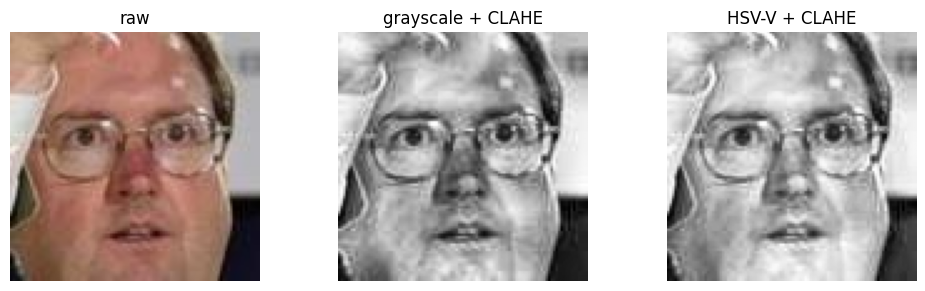

In [2]:
def load_gray_clahe(rel_path: str, size=TARGET):
    img = cv2.imread(str(ROOT / rel_path), cv2.IMREAD_GRAYSCALE)
    if img.shape[:2] != size:
        img = cv2.resize(img, size[::-1])
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(img)

def load_hsv_v(rel_path: str, size=TARGET):
    img = cv2.imread(str(ROOT / rel_path), cv2.IMREAD_COLOR)
    if img.shape[:2] != size:
        img = cv2.resize(img, size[::-1])
    v = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)[..., 2]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(v)

# Visualize the preprocessing on one example
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
sample = SPLIT["train"][0]["path"]
raw = cv2.cvtColor(cv2.imread(str(ROOT / sample)), cv2.COLOR_BGR2RGB)
ax[0].imshow(raw); ax[0].set_title("raw"); ax[0].axis("off")
ax[1].imshow(load_gray_clahe(sample), cmap="gray"); ax[1].set_title("grayscale + CLAHE"); ax[1].axis("off")
ax[2].imshow(load_hsv_v(sample),       cmap="gray"); ax[2].set_title("HSV-V + CLAHE");    ax[2].axis("off")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye02_preprocess_demo.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Edge detection demo — Canny with auto-tuned thresholds

Auto-tuning rule: compute the median intensity `m`, set `lower = max(0, 0.66·m)` and `upper = min(255, 1.33·m)` — a published heuristic that adapts to per-image brightness, defensible in the paper and reproducible across machines.

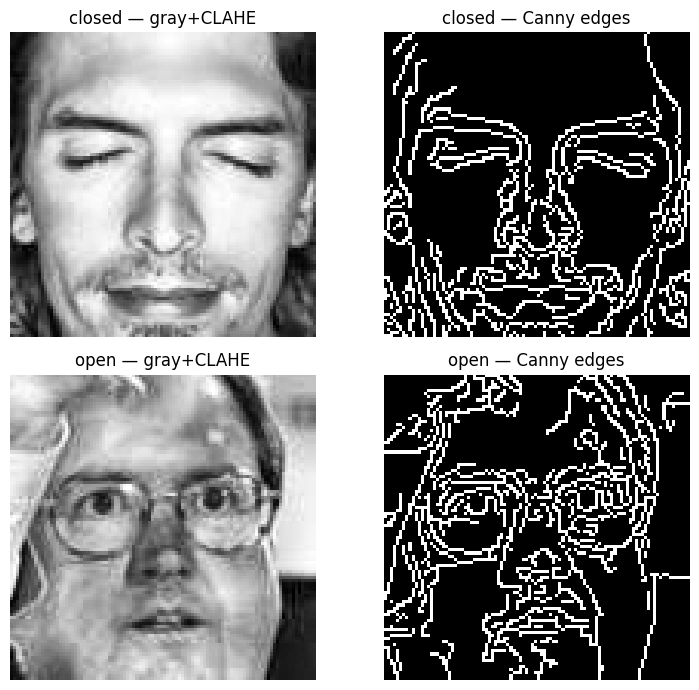

In [3]:
def auto_canny(gray):
    m = float(np.median(gray))
    lo = int(max(0, 0.66 * m)); hi = int(min(255, 1.33 * m))
    return cv2.Canny(gray, lo, hi)

closed_ex = next(r for r in SPLIT["train"] if r["label"] == 0)["path"]
open_ex   = next(r for r in SPLIT["train"] if r["label"] == 1)["path"]
fig, ax = plt.subplots(2, 2, figsize=(8, 7))
for row, (ex, name) in enumerate([(closed_ex, "closed"), (open_ex, "open")]):
    g = load_gray_clahe(ex); e = auto_canny(g)
    ax[row, 0].imshow(g, cmap="gray"); ax[row, 0].set_title(f"{name} — gray+CLAHE"); ax[row, 0].axis("off")
    ax[row, 1].imshow(e, cmap="gray"); ax[row, 1].set_title(f"{name} — Canny edges"); ax[row, 1].axis("off")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye02_canny_demo.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Optional shape detection — Hough circle (iris) — visual only

Per the plan, the iris circle is detected for the paper as evidence that classical shape cues are extractable but it is **not** fed to the SVM (would require eye-region pre-cropping that we don't do here).

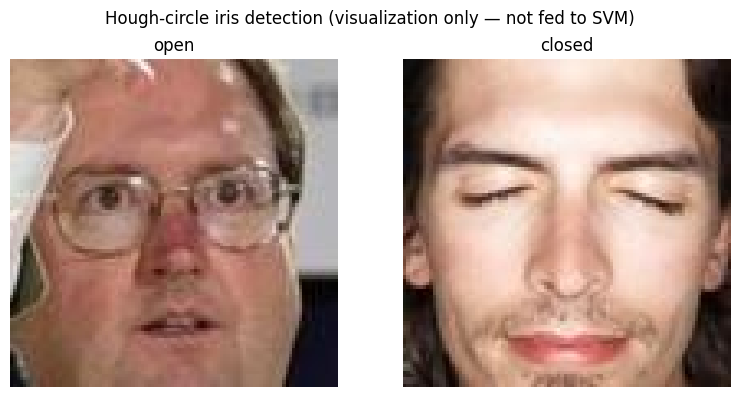

In [4]:
def hough_iris(rgb):
    g = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    g = cv2.medianBlur(g, 5)
    c = cv2.HoughCircles(g, cv2.HOUGH_GRADIENT, dp=1, minDist=20,
                          param1=50, param2=20, minRadius=4, maxRadius=15)
    return c

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for col, (ex, name) in enumerate([(open_ex, "open"), (closed_ex, "closed")]):
    rgb = cv2.cvtColor(cv2.imread(str(ROOT / ex)), cv2.COLOR_BGR2RGB).copy()
    c = hough_iris(rgb)
    if c is not None:
        for x, y, r in np.round(c[0]).astype(int):
            cv2.circle(rgb, (x, y), r, (255, 0, 0), 2)
    ax[col].imshow(rgb); ax[col].set_title(f"{name}"); ax[col].axis("off")
fig.suptitle("Hough-circle iris detection (visualization only — not fed to SVM)")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye02_hough_demo.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Color-space CV comparison

5-fold cross-validation on the **training split only** comparing grayscale-CLAHE vs HSV-V-CLAHE under identical HOG+linear-SVM. Picks the winner used downstream.

In [5]:
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

HOG_PARAMS = dict(pixels_per_cell=(8, 8), cells_per_block=(2, 2), orientations=9, transform_sqrt=True, feature_vector=True)

def features(loader, recs):
    X = np.stack([hog(loader(r["path"]), **HOG_PARAMS) for r in recs])
    y = np.array([r["label"] for r in recs])
    return X, y

print("Extracting features (grayscale)...")
X_gray, y_gray = features(load_gray_clahe, SPLIT["train"])
print("Extracting features (HSV-V) ...")
X_hsv,  y_hsv  = features(load_hsv_v,     SPLIT["train"])
print(f"feature dim: {X_gray.shape[1]}  |  train size: {X_gray.shape[0]}")

def cv_score(X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    pipe = Pipeline([("sc", StandardScaler()), ("svm", LinearSVC(C=1.0, max_iter=5000, random_state=SEED))])
    scores = []
    for tr, va in skf.split(X, y):
        pipe.fit(X[tr], y[tr])
        scores.append(accuracy_score(y[va], pipe.predict(X[va])))
    return np.mean(scores), np.std(scores)

m_gray, s_gray = cv_score(X_gray, y_gray)
m_hsv,  s_hsv  = cv_score(X_hsv,  y_hsv)
print(f"grayscale + CLAHE : {m_gray:.4f} ± {s_gray:.4f}")
print(f"HSV-V     + CLAHE : {m_hsv:.4f} ± {s_hsv:.4f}")
COLOR_SPACE = "gray" if m_gray >= m_hsv else "hsv_v"
print(f"\n→ Picking '{COLOR_SPACE}' for the rest of the notebook.")

Extracting features (grayscale)...


Extracting features (HSV-V) ...


feature dim: 4356  |  train size: 1696


grayscale + CLAHE : 0.8585 ± 0.0161
HSV-V     + CLAHE : 0.8691 ± 0.0123

→ Picking 'hsv_v' for the rest of the notebook.


## 5. Grid-search the chosen pipeline on train, evaluate on test

`GridSearchCV` over `C ∈ {0.1, 1, 10}` with 5-fold CV on train. We refit on the full training split using the best `C` and evaluate on the held-out test split.

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score, roc_curve, auc)

loader = load_gray_clahe if COLOR_SPACE == "gray" else load_hsv_v
X_train, y_train = features(loader, SPLIT["train"])
X_val,   y_val   = features(loader, SPLIT["val"])
X_test,  y_test  = features(loader, SPLIT["test"])

pipe = Pipeline([("sc", StandardScaler()), ("svm", LinearSVC(max_iter=5000, random_state=SEED))])
grid = GridSearchCV(pipe, {"svm__C": [0.1, 1.0, 10.0]}, cv=5, n_jobs=-1, scoring="accuracy")
grid.fit(X_train, y_train)
print("CV results:")
print(pd.DataFrame(grid.cv_results_)[["param_svm__C", "mean_test_score", "std_test_score"]].round(4))
print(f"\nbest C = {grid.best_params_['svm__C']}")

CV results:
   param_svm__C  mean_test_score  std_test_score
0           0.1           0.8709          0.0204
1           1.0           0.8709          0.0204
2          10.0           0.8709          0.0204

best C = 0.1


In [7]:
best = grid.best_estimator_
y_pred = best.predict(X_test)
acc   = (y_pred == y_test).mean()
prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred)
print(f"TEST  accuracy={acc:.4f}  precision={prec:.4f}  recall={rec:.4f}  f1={f1:.4f}\n")
print(classification_report(y_test, y_pred, target_names=["closed", "open"], digits=4))

TEST  accuracy=0.8736  precision=0.8717  recall=0.8811  f1=0.8763

              precision    recall  f1-score   support

      closed     0.8757    0.8659    0.8708       179
        open     0.8717    0.8811    0.8763       185

    accuracy                         0.8736       364
   macro avg     0.8737    0.8735    0.8736       364
weighted avg     0.8736    0.8736    0.8736       364



## 6. Confusion matrix + ROC curve (visual deliverables)

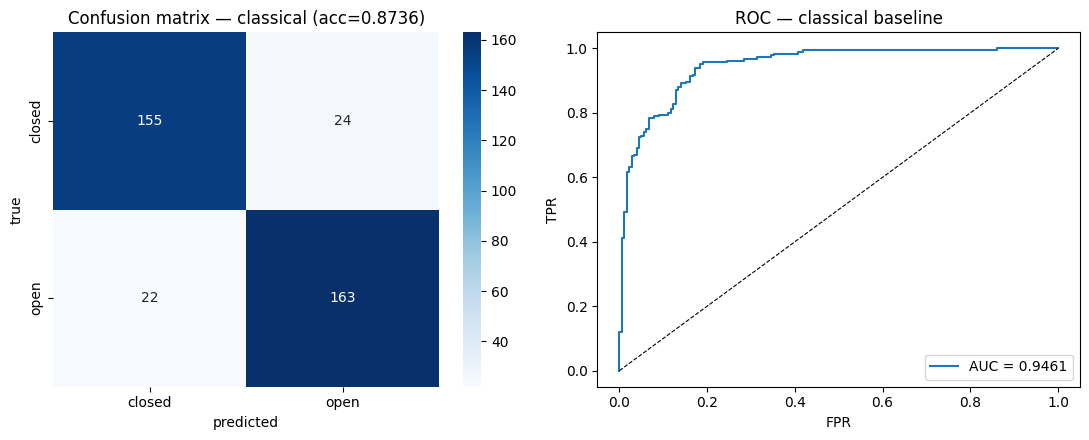

In [8]:
# Confusion matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["closed", "open"], yticklabels=["closed", "open"], ax=ax[0])
ax[0].set_xlabel("predicted"); ax[0].set_ylabel("true")
ax[0].set_title(f"Confusion matrix — classical (acc={acc:.4f})")

# ROC — use decision_function for LinearSVC
scores = best.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, scores)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
ax[1].plot([0, 1], [0, 1], "k--", lw=0.8)
ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR"); ax[1].set_title("ROC — classical baseline"); ax[1].legend()

plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye02_cm_and_roc.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Save metrics for cross-notebook comparison

Notebook 06 (model selection) and notebook 09 (paper figures) both read this JSON to put the classical baseline into the cross-method comparison table.

In [9]:
results = {
    "model": "classical_hog_svm",
    "color_space": COLOR_SPACE,
    "best_C": float(grid.best_params_["svm__C"]),
    "accuracy": float(acc),
    "precision": float(prec),
    "recall": float(rec),
    "f1": float(f1),
    "auc": float(roc_auc),
    "confusion_matrix": cm.tolist(),
    "feature_dim": int(X_train.shape[1]),
    "n_params": int(X_train.shape[1] + 1),  # linear SVM weights + bias
    "test_size": int(len(y_test)),
}
out_path = ROOT / "artifacts" / "eye02_classical_results.json"
with open(out_path, "w") as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))

{
  "model": "classical_hog_svm",
  "color_space": "hsv_v",
  "best_C": 0.1,
  "accuracy": 0.8736263736263736,
  "precision": 0.8716577540106952,
  "recall": 0.8810810810810811,
  "f1": 0.8763440860215054,
  "auc": 0.9460667371281898,
  "confusion_matrix": [
    [
      155,
      24
    ],
    [
      22,
      163
    ]
  ],
  "feature_dim": 4356,
  "n_params": 4357,
  "test_size": 364
}


## Summary

The classical HOG + linear-SVM baseline is **strong on CEW** because the dataset is small, well-cropped, and the class-defining cue is local-texture-around-the-eyes — exactly what HOG encodes. This is the reference accuracy that the custom CNN in Notebook 03 needs to beat to justify deep learning.